In [1]:
# 7-18-2026

In [8]:
import zarr
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
ds = xr.open_zarr("seasfire_filtered.zarr", consolidated=True)

In [6]:
list(ds.data_vars)

['area',
 'biomes',
 'cams_co2fire',
 'cams_frpfire',
 'drought_code_max',
 'drought_code_mean',
 'fcci_ba',
 'fcci_ba_valid_mask',
 'fcci_fraction_of_burnable_area',
 'fcci_fraction_of_observed_area',
 'fcci_number_of_patches',
 'fwi_max',
 'fwi_mean',
 'gwis_ba',
 'gwis_ba_valid_mask',
 'lai',
 'lccs_class_1',
 'lccs_class_2',
 'lccs_class_3',
 'lccs_class_4',
 'lccs_class_6',
 'lccs_class_7',
 'lsm',
 'lst_day',
 'ndvi',
 'pop_dens',
 'rel_hum',
 'skt',
 'ssr',
 'ssrd',
 'sst',
 'swvl1',
 'swvl2',
 'swvl3',
 'swvl4',
 't2m_max',
 't2m_mean',
 't2m_min',
 'tp',
 'vpd',
 'ws10']

In [7]:
# check dims/shape before assuming anything, seasfire vars can carry a time dim even for slow-changing fields
for c in ["lccs_class_1", "lccs_class_2", "lccs_class_3", "lccs_class_4", "lccs_class_6", "lccs_class_7"]:
    print(c, ds[c].dims, ds[c].shape)

lccs_class_1 ('time', 'latitude', 'longitude') (506, 720, 1440)
lccs_class_2 ('time', 'latitude', 'longitude') (506, 720, 1440)
lccs_class_3 ('time', 'latitude', 'longitude') (506, 720, 1440)
lccs_class_4 ('time', 'latitude', 'longitude') (506, 720, 1440)
lccs_class_6 ('time', 'latitude', 'longitude') (506, 720, 1440)
lccs_class_7 ('time', 'latitude', 'longitude') (506, 720, 1440)


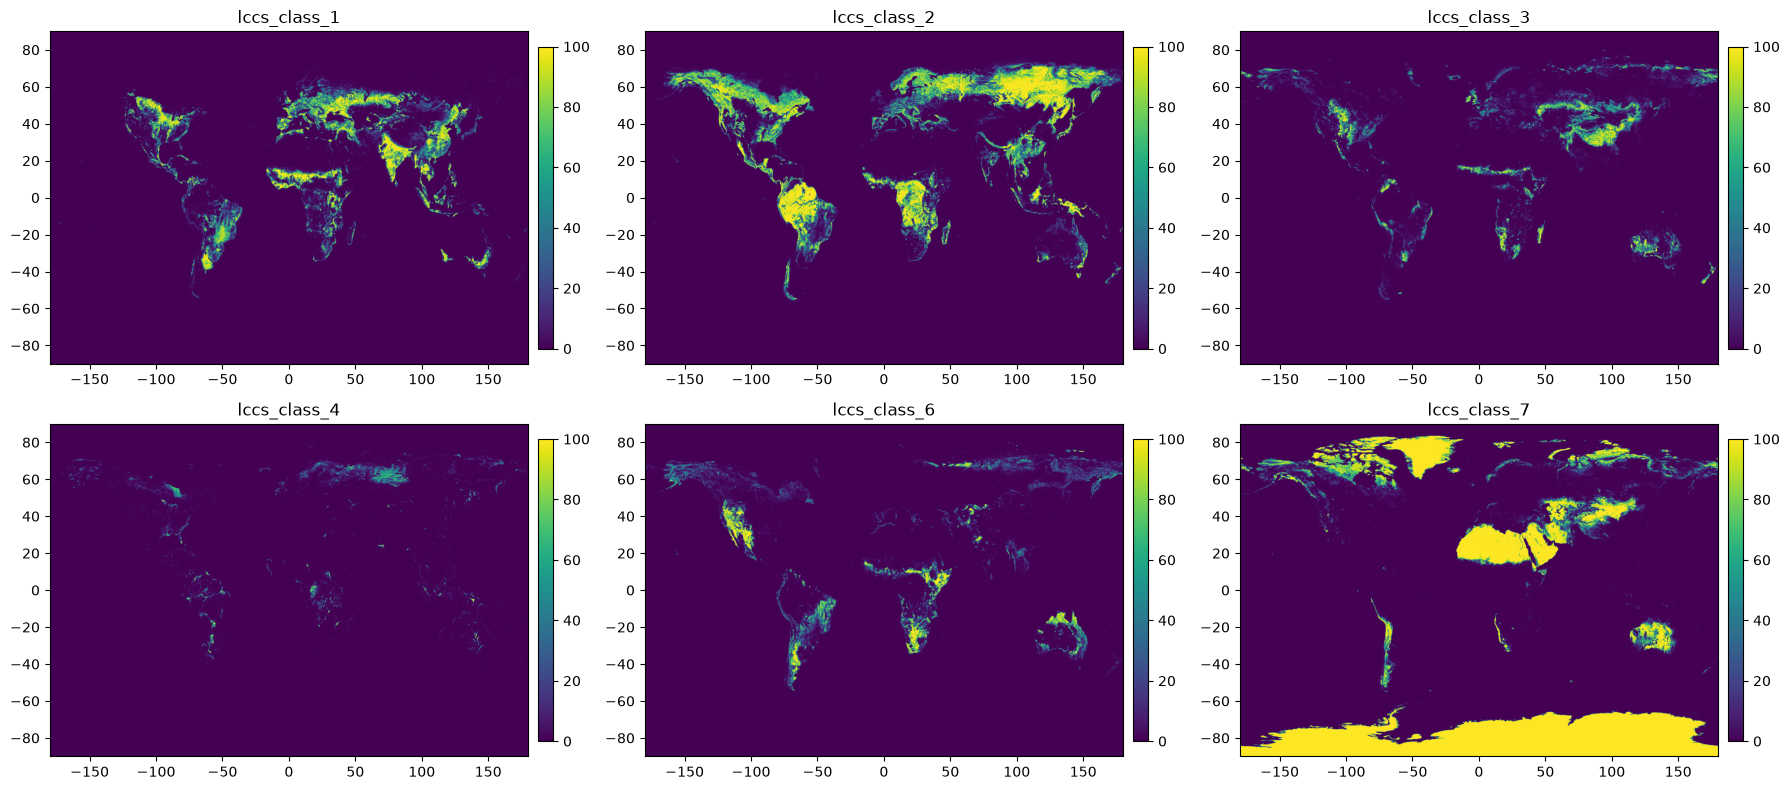

In [9]:
lccs_vars = ["lccs_class_1", "lccs_class_2", "lccs_class_3", "lccs_class_4", "lccs_class_6", "lccs_class_7"]

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for ax, var in zip(axes.flat, lccs_vars):
    data_2d = ds[var].mean(dim="time").values
    im = ax.imshow(
        data_2d,
        origin="upper",
        extent=[-180, 180, -90, 90],
        cmap="viridis",
        aspect="auto",
    )
    ax.set_title(var)
    fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)

plt.tight_layout()
plt.show()

In [10]:
domains = xr.open_zarr("ecoregion_domains.zarr", consolidated=True)
print(domains.dims, domains.coords["latitude"].values[:3], domains.coords["longitude"].values[:3])
print(ds.dims, ds.coords["latitude"].values[:3] if "latitude" in ds.coords else ds.coords)

FrozenMappingWarningOnValuesAccess({'latitude': 720, 'longitude': 1440}) [89.875 89.625 89.375] [-179.875 -179.625 -179.375]
FrozenMappingWarningOnValuesAccess({'latitude': 720, 'longitude': 1440, 'time': 506}) [89.875 89.625 89.375]


In [11]:
lccs_vars = ["lccs_class_1", "lccs_class_2", "lccs_class_3", "lccs_class_4", "lccs_class_6", "lccs_class_7"]

# collapse time dim once here, reused for both plot and table
lccs_means = {v: ds[v].mean(dim="time").values for v in lccs_vars}

domain_vals = domains["domain_id"].values
used_domains = [0, 1, 2, 4, 5, 6, 7, 8, 11, 12, 13, 16, 18, 19, 20, 21, 22, 23, 25, 26, 27, 28, 29, 30, 32, 33, 36, 37, 38, 39, 45, 46, 47, 49]

In [ ]:
len(used_domains) # good

34

In [14]:
rows = []
for d in used_domains:
    mask = domain_vals == d
    row = {"domain": d, "n_cells": int(mask.sum())}
    for v in lccs_vars:
        row[v] = round(float(np.nanmean(lccs_means[v][mask])), 2)
    rows.append(row)

lccs_df = pd.DataFrame(rows)
lccs_df.to_csv("domain_lccs_pcts.csv", index=False)
lccs_df.head()

,domain,n_cells,lccs_class_1,lccs_class_2,lccs_class_3,lccs_class_4,lccs_class_6,lccs_class_7
0,0,13812,31.21,34.20,9.53,3.92,18.32,0.38
1,1,6356,3.45,86.99,3.15,2.97,1.87,0.22
2,2,7325,0.14,3.13,19.29,1.92,18.36,56.61
3,4,51331,7.72,55.99,6.93,5.15,5.74,13.67
4,5,5788,51.26,36.73,0.80,0.61,6.07,0.08


In [ ]:
lccs_df.drop(["domain", "n_cells"], axis=1).sum(axis=1) # not full because missing some classes or unmapped pixels

0     97.56
1     98.65
2     99.45
3     95.20
4     95.55
5     92.11
6     96.49
7     90.08
8     98.34
9     97.42
10    99.50
11    98.22
12    98.73
13    97.25
14    98.01
15    97.11
16    96.02
17    95.30
18    99.05
19    94.12
20    97.71
21    92.74
22    94.56
23    99.70
24    98.92
25    97.64
26    98.72
27    98.29
28    95.80
29    98.69
30    99.32
31    87.83
32    95.49
33    86.51
dtype: float64

In [21]:
lccs_only = lccs_df.drop(columns=["domain", "n_cells"])

dominant_rows = []
for i, row in lccs_df.iterrows():
    pcts = lccs_only.loc[i]
    top_class = pcts.idxmax()
    top_pct = pcts.max()

    if top_pct > 50:
        dominant_rows.append({
            "domain": row["domain"],
            "dominant_lccs": top_class,
            "pct": round(top_pct, 2),
        })

print(f"{len(dominant_rows)} / {len(used_domains)} domains mapped to a >50% class")

dominant_lccs_df = pd.DataFrame(dominant_rows)
dominant_lccs_df.to_csv("domain_dominant_lccs.csv", index=False)
dominant_lccs_df

19 / 34 domains mapped to a >50% class


,domain,dominant_lccs,pct
0,1.0,lccs_class_2,86.99
1,2.0,lccs_class_7,56.61
2,4.0,lccs_class_2,55.99
3,5.0,lccs_class_1,51.26
4,6.0,lccs_class_2,51.69
5,11.0,lccs_class_2,50.04
6,12.0,lccs_class_1,73.78
7,13.0,lccs_class_7,86.14
8,16.0,lccs_class_7,54.40
9,18.0,lccs_class_6,59.20
